Introduce los límites en el eje x para la gráfica de la gaussiana (entre 0 y 0.40):
Límite derecho:
Límite izquierdo:


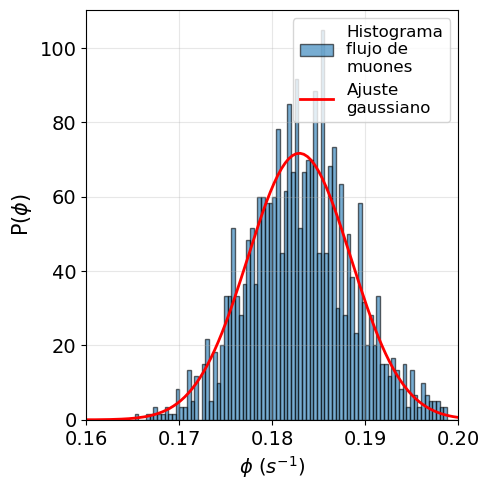

Media (mu) = 0.182897 s^-1
Anchura (sigma) = 0.005560 s^-1
Área gaussiana: 1.0


In [ ]:
##############################################################################################
# Introduzca el nombre del archivo con los datos a analizar en "Nombre_del_archivo_con_los_datos.txt",
# este archivo debe tener 3 columnas: Evento, Tiempo_efectivo (s), flujo (s^-1); y una primera fila con los nombres de las columnas.
# El programa realizará un histograma con 1000 bins, y el ajuste gaussiano correspondiente, esta figura se guardará con el nombre "Nombre_de_la_imagen.png".
# El usuario introducirá los límites del eje x para la figura, ajustándolos para que la gráfica realizada se vea lo mejor posible
# El programa mostrará por pantalla los valores de la media (mu) y la anchura (sigma) del ajuste gaussiano, así como el área bajo la curva gaussiana ajustada.
##############################################################################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Extraigo los datos del archivo de texto y los guardo en una matriz Nx3
Matriz_datos = np.loadtxt("Nombre_del_archivo_con_los_datos.txt", skiprows=1)

# Extraigo las columnas de la matriz
Evento = Matriz_datos[:, 0]
Tiempo_efectivo = Matriz_datos[:, 1]
Flujo_muones = Matriz_datos[:, 2]

# Defino la funcion gaussiana para ajustar el histograma
def gaussiana(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Histograma para ajuste (cuentas por bin)
num_bins = 1000
cuentas, bordes = np.histogram(Flujo_muones, bins=num_bins, range=(0, 0.40), density = True)
centros = 0.5 * (bordes[:-1] + bordes[1:])

# Evito bins vacios para estabilizar el ajuste
x_fit = centros[cuentas > 0]
y_fit = cuentas[cuentas > 0]

# Valores iniciales razonables para el ajuste
A0 = np.max(y_fit)
mu0 = np.mean(Flujo_muones)
sigma0 = np.std(Flujo_muones)

parametros, cov = curve_fit(gaussiana, x_fit, y_fit, p0=[A0, mu0, sigma0])
A_fit, mu_fit, sigma_fit = parametros
err_A, err_mu, err_sigma = np.sqrt(np.diag(cov))

# Dibujo histograma
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(Flujo_muones, bins=num_bins, range=(0, 0.40), edgecolor="black", alpha=0.6, label="Histograma\nflujo de\nmuones", density = True)

# Dibujo la curva gaussiana ajustada
x_modelo = np.linspace(0, 0.40, 1000)
y_modelo = gaussiana(x_modelo, A_fit, mu_fit, sigma_fit)
ax.plot(x_modelo, y_modelo, "r-", lw=2, label="Ajuste\ngaussiano")

# El usuario introduce los límites para la figura
print("Introduce los límites en el eje x para la gráfica de la gaussiana (entre 0 y 0.40):")
print("Límite derecho:")
lim_max = float(input())
print("Límite izquierdo:")
lim_min = float(input())

ax.set_xlabel(r"$\phi$ ($s^{-1}$)", fontsize=14)
ax.set_ylabel(r"P($\phi$)", fontsize=15)
ax.tick_params(axis="both", labelsize=14)
ax.set_xlim(lim_min, lim_max)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize = 12)

fig.tight_layout()
fig.savefig("Nombre_de_la_imagen.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()

print(f"Media (mu) = {mu_fit:.6f} s^-1")
print(f"Anchura (sigma) = {sigma_fit:.6f} s^-1")

# Compro el área bajo la curva gaussiana ajustada para verificar que es aproximadamente 1
area = np.sum(cuentas * np.diff(bordes))
print(f"Área gaussiana: {area}")